In [ ]:
# Create a Machine Learning that can predict profit based on sales and other features, (Regression Task)
# Predict Customer Type based on transaction data, (Classification Task)
'''
1. Import necessary libraries
2. Load the dataset and Explore (EDA) the data
3. Preprocess the data (handle missing values, encode categorical variables, feature scaling)
4. Split the dataset into training and testing sets
5. Train a regression model to predict profit based on sales and other features
6. Evaluate the regression model using appropriate metrics (e.g., RMSE, R-squared)
7. Train a classification model to predict customer type based on transaction data
8. Evaluate the classification model using appropriate metrics (e.g., accuracy, precision, recall, F1-score)
9. Visualize the results and interpret the findings 


'''

In [26]:
# step 1: import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# import sci - kit fr machine learning
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [27]:
# step 2: load the dataset and explore (EDA) hte data
# load the dataset
df = pd.read_csv('ecommerce_bigdata.csv')
#display the first 5 rows of the dataset
df.head()

,TransactionID,Date,Region,ProductCategory,CustomerType,Sales,Profit
0,TX0001,2026-06-16,Eastern,Electronics,Wholesale,4924,359.44
1,TX0002,2026-02-12,Central,Electronics,Retail,3283,944.32
2,TX0003,2026-03-01,Northern,Food,Online,4049,967.10
3,TX0004,2026-06-03,Western,Household Products,Online,4331,434.57
4,TX0005,2026-01-21,Western,Household Products,Retail,3283,340.48


In [28]:

# Preprocess the data (handle missing values, encode categorical variables, feature scaling)

# Check for empty values in the dataset
# Check for Duplicate rows
# Wrong format of data in the dataset
# Wrong data type in the dataset

#df = df.dropna()  # Handle missing values

# Check for missing values
df.isnull().sum()

TransactionID      0
Date               0
Region             0
ProductCategory    0
CustomerType       0
Sales              0
Profit             0
dtype: int64

In [29]:
#summary statistics of the datatset
df.describe()

,Sales,Profit
count,200.000000,200.000000
mean,2567.190000,456.367350
std,1528.736925,346.853151
min,56.000000,5.130000
25%,1200.500000,173.967500
50%,2428.000000,379.330000
75%,4052.000000,675.000000
max,4998.000000,1377.040000


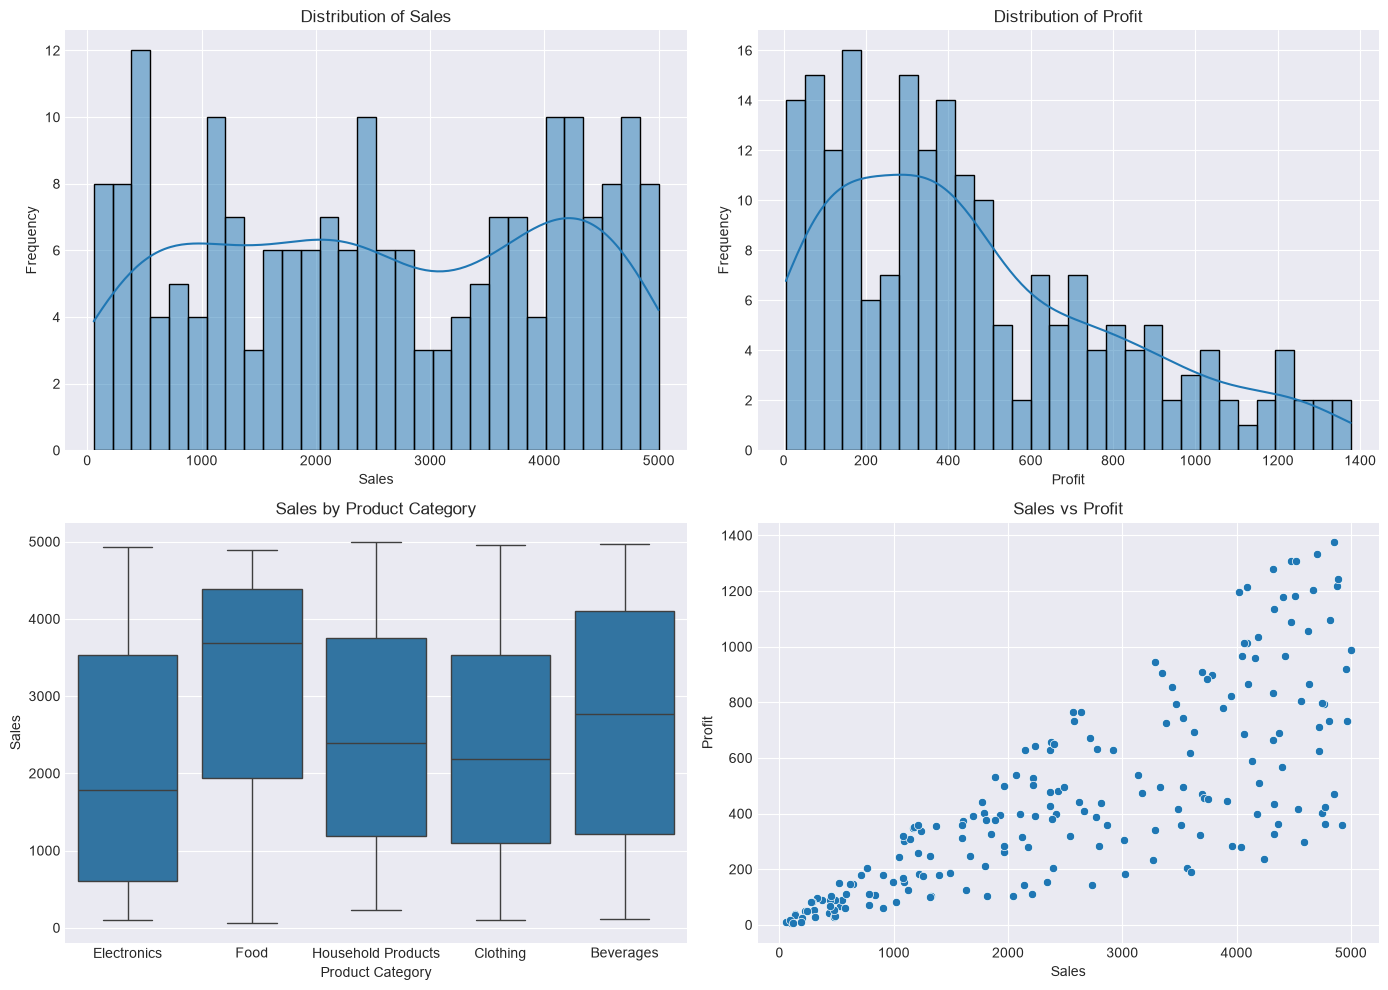

In [30]:
# Data Visualization
# Setup the plotting style
plt.style.use('seaborn-v0_8-darkgrid')
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
# 1 Plot Distribution of Sales
sns.histplot(df['Sales'], bins=30, kde=True, ax=axes[0, 0])
axes[0, 0].set_title('Distribution of Sales')
axes[0, 0].set_xlabel('Sales')
axes[0, 0].set_ylabel('Frequency')
# 2 Plot Distribution of Profit
sns.histplot(df['Profit'], bins=30, kde=True, ax=axes[0, 1])
axes[0, 1].set_title('Distribution of Profit')
axes[0, 1].set_xlabel('Profit')
axes[0, 1].set_ylabel('Frequency')

# exercise
# plot sales by product category (boxplot)
sns.boxplot(x='ProductCategory', y='Sales', data=df, ax=axes[1, 0])
axes[1, 0].set_title('Sales by Product Category')
axes[1, 0].set_xlabel('Product Category')
axes[1, 0].set_ylabel('Sales')

# 4. Relationship Between Sales and Profit (Scatter Plot)
sns.scatterplot(x='Sales', y='Profit', data=df, ax=axes[1, 1])
axes[1, 1].set_title('Sales vs Profit')
axes[1, 1].set_xlabel('Sales')
axes[1, 1].set_ylabel('Profit')

# Adjust layout
plt.tight_layout()

# Display plots
plt.show()

In [31]:
# Step 4: 3. Feature Engineering: Selecting and creating relevant features that will help the model learn better.
# Create a copy of the original dataframe to avoid modifying it directly
df_processed = df.copy()


# Convert Date to datetime format and extract relevant features (e.g., year, month, day)
df_processed['Date'] = pd.to_datetime(df_processed['Date'])
df_processed['Month'] = df_processed['Date'].dt.month
df_processed['Day'] = df_processed['Date'].dt.day
df_processed['Weekday'] = df_processed['Date'].dt.weekday

In [32]:
"""
What happens if we don't convert categorical variables to numbers?
"""
#why? machine learning algorithms work with numerical data. Most algorithms cannot handle categorical data directly, as they rely on mathematical operations that require numerical inputs. If categorical variables are not converted to numbers, the model may not be able to interpret the data correctly, leading to poor performance or errors during training.

label_encoder = {}
categorical_columns = ['Region', 'ProductCategory', 'CustomerType'] # Replace with your categorical columns
for col in categorical_columns:
    le = LabelEncoder()
    df_processed[col + '_Encoded'] = le.fit_transform(df_processed[col])
    label_encoder[col] = le # Store the label encoder for future use
    print(f'Encoded {col}: {dict(zip(le.classes_, le.transform(le.classes_)))}')


Encoded Region: {'Central': np.int64(0), 'Eastern': np.int64(1), 'Northern': np.int64(2), 'Western': np.int64(3)}
Encoded ProductCategory: {'Beverages': np.int64(0), 'Clothing': np.int64(1), 'Electronics': np.int64(2), 'Food': np.int64(3), 'Household Products': np.int64(4)}
Encoded CustomerType: {'Online': np.int64(0), 'Retail': np.int64(1), 'Wholesale': np.int64(2)}


In [33]:
# Drop the orignal categorical columns after encoding and TransactionID (Not useful for prediction)

# Drop the original categorical columns after encoding and TransactionID (Not useful for prediction)
df_processed.drop(['TransactionID', 'Date', 'Region', 'ProductCategory', 'CustomerType'], axis=1, inplace=True)
print("Processed DataFrame after encoding and dropping unnecessary columns:")
df_processed.head()

Processed DataFrame after encoding and dropping unnecessary columns:


,Sales,Profit,Month,Day,Weekday,Region_Encoded,ProductCategory_Encoded,CustomerType_Encoded
0,4924,359.44,6,16,1,1,2,2
1,3283,944.32,2,12,3,0,2,1
2,4049,967.10,3,1,6,2,3,0
3,4331,434.57,6,3,2,3,4,0
4,3283,340.48,1,21,2,3,4,1


In [34]:
# step 5: Split the data into training and testing sets
# define features and target variable for regression task (predicting profit)
# Rgression task: Predicting Profit based on sales

print('regression: Predicting Profit based on Sales and other features')

# Prepare features and target variable for regression task
X_regression = df_processed.drop('Profit', axis=1) #Features (all columns except 'Profit')
y_regression = df_processed['Profit'] # Target variable (Profit)

# Split the dataset into training and testing sets for regression task
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(X_regression, y_regression, test_size=0.2, random_state=42)

# what is a random State?
# Random state is a seed value that ensures reproducibility of the results. When you set a random state, it guarantees that the random processes (like shuffling and splitting the data) will produce the same results every time you run the code. This is important for consistency in experiments and comparisons.

print("Regression data split: ")
print(f"Training set size: {X_train_reg.shape[0]} samples")
print(f"Testing set size: {X_test_reg.shape[0]} samples")

regression: Predicting Profit based on Sales and other features
Regression data split: 
Training set size: 160 samples
Testing set size: 40 samples


In [35]:
# Train multiple regression models and evaluate their performance
# 1. Linear Regression
# 2. Decision Tree Regressor
# 3. Random Forest Regressor

regression_models = {
    'Linear Regression': LinearRegression(),
    'Decision Tree Regressor': DecisionTreeRegressor(random_state=42),
    'Random Forest Regressor': RandomForestRegressor(random_state=42)
}

print("\nRegression Model Evaluation:")
regression_results = {}

for name, model in regression_models.items():
    # Train the model
    model.fit(X_train_reg, y_train_reg)
    
    # Make predictions on the test set
    y_pred_reg = model.predict(X_test_reg)
    
    # Evaluate the model and calculate RMSE and R-squared
    rmse = np.sqrt(mean_squared_error(y_test_reg, y_pred_reg))
    r2 = r2_score(y_test_reg, y_pred_reg)
    
    regression_results[name] = {'RMSE': rmse, 'R-squared': r2}
    
    print(f"{name}: RMSE = {rmse:.4f}, R-squared = {r2:.4f}")

    # Store results 
    regression_results[name] = {
        'model': model,
        'RMSE': rmse,
        'mse': mean_squared_error(y_test_reg, y_pred_reg),
        'R-squared': r2,
        'predicted_profit': y_pred_reg
    }

    print(f"{name} model trained and evaluated successfully.")
    print(f"Mean Squared Error (MSE): {regression_results[name]['mse']:.2f}")
    print(f"Root Mean Squared Error (RMSE): {regression_results[name]['RMSE']:.4f}")
    print(f"R-squared: {regression_results[name]['R-squared']:.4f}")
    print(f"Interpretation: {regression_results[name]['predicted_profit'][:5]}")  # Display first 5 prediction


Regression Model Evaluation:
Linear Regression: RMSE = 177.1111, R-squared = 0.7223
Linear Regression model trained and evaluated successfully.
Mean Squared Error (MSE): 31368.35
Root Mean Squared Error (RMSE): 177.1111
R-squared: 0.7223
Interpretation: [ 73.20909964 623.81900778 616.51180497 869.47326722 711.15104551]
Decision Tree Regressor: RMSE = 347.3747, R-squared = -0.0681
Decision Tree Regressor model trained and evaluated successfully.
Mean Squared Error (MSE): 120669.20
Root Mean Squared Error (RMSE): 347.3747
R-squared: -0.0681
Interpretation: [  68.67  340.48  471.53  623.6  1056.23]
Random Forest Regressor: RMSE = 218.0138, R-squared = 0.5793
Random Forest Regressor model trained and evaluated successfully.
Mean Squared Error (MSE): 47530.02
Root Mean Squared Error (RMSE): 218.0138
R-squared: 0.5793
Interpretation: [ 68.1485 462.9027 554.7863 787.9254 917.2376]


In [ ]:
# Assignment 1: do the Classification Task: Predicting Customer Type based on transaction data
'''
- Logistic Regression
- Decision Tree Classifier
- Random Forest Classifier
'''

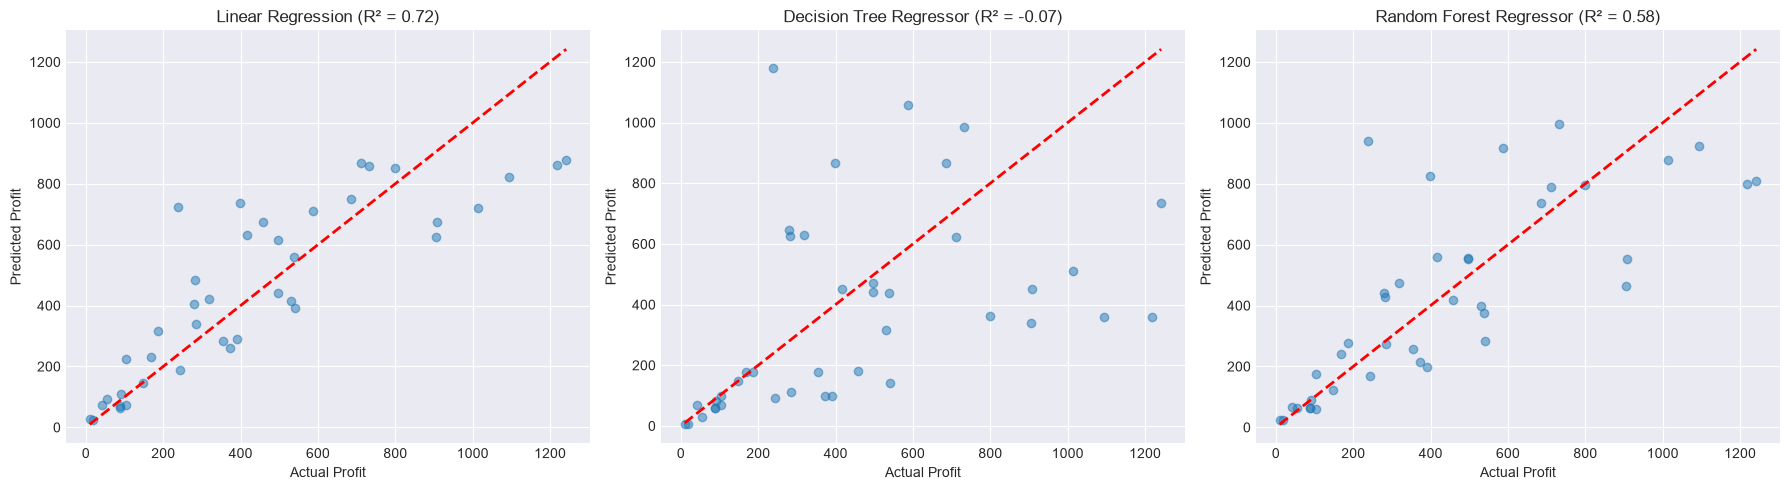

Regression models evaluated and visualized successfully.


<Figure size 640x480 with 0 Axes>

In [36]:
# Visualize the results and interpret the findings
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, (name, result) in enumerate(regression_results.items()):
    axes[i].scatter(y_test_reg, result['predicted_profit'], alpha=0.5)
    axes[i].plot([y_test_reg.min(), y_test_reg.max()], [y_test_reg.min(), y_test_reg.max()], 'r--', lw=2)
    axes[i].set_title(f"{name} (R² = {result['R-squared']:.2f})")
    axes[i].set_xlabel('Actual Profit')
    axes[i].set_ylabel('Predicted Profit')

plt.tight_layout()
plt.show()
print("Regression models evaluated and visualized successfully.")
plt.savefig('regression_model_evaluation.png')  # Save the figure as a PNG file

In [ ]:
# Key Learnings:
''' 
1. Data preprocessing is crucial for machine learning tasks, including handling missing values and encoding categorical variables.
2. Regression models can be evaluated using metrics like RMSE and R-squared, which provide insights into model performance.
3. Assignment 1: Classification Task: Predicting Customer Type based on transaction data can be approached using Logistic Regression, Decision Tree Classifier, and Random Forest Classifier.
4. Model evaluation and visualization help in understanding the performance of different models and selecting the best one for deployment.
5. Feature engineering, such as creating new features from existing data, can significantly improve model performance.
6. Feature importance analysis can help identify the most influential features of Random Forest models, aiding in feature selection and model interpretability.

Business Insights:
1. Understanding the relationship between sales and profit can help businesses optimize their pricing strategies and product offerings
2. Predicting customer type based on transaction data can enable targeted marketing campaigns and personalized customer experiences.
3. The insights gained from regression and classification models can inform strategic decision-making, leading to increased profitability and customer satisfaction.

Recommendations:
1. Use Random Forest Regressor for predicting profit based on sales and other features, as it provides the best performance among the evaluated models.


2. For predicting customer type, consider using Random Forest Classifier, as it can handle complex relationships and interactions between features effectively.
3. Continuously monitor and update the models with new data to maintain their accuracy and relevance in a dynamic business environment.
4. Explore additional features and data sources that

'''